# Bragg Disk Detection

In this notebook, we are detecting Bragg disks from diffraction patterns using a 4D-STEM dataset.

Sources:
- Using a subset of data from the [Serin Lee dataset](10.5281/zenodo.18167694)
- Also following steps and explanations from the [py4DSTEM Disk Detection tutorial](https://github.com/py4dstem/py4DSTEM_tutorials/blob/main/notebooks/basics_02_diskdetection.ipynb)

### Import packages, load data and create datacube

Import py4DSTEM and other required libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import py4DSTEM
from py4DSTEM.visualize import show
py4DSTEM.__version__

C:\Users\alahe\anaconda3\envs\py4dstem\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
C:\Users\alahe\anaconda3\envs\py4dstem\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH

'0.14.19'

Load the 4D-STEM Serin Lee dataset.

In [2]:
dataset = np.load('Datasets/SerinLee_cut2.npy')
np.shape(dataset)

(60, 60, 192, 192)

Create datacube using Serin Lee data, where the datacube holds the 4D values and select electron beam values for angle and energy.

In [3]:
semiangle_convergence_mrad = 0.622
energy = 300e3
datacube = py4DSTEM.DataCube(data=dataset)
datacube

DataCube( A 4-dimensional array of shape (60, 60, 192, 192) called 'datacube',
          with dimensions:

              Rx = [0,1,2,...] pixels
              Ry = [0,1,2,...] pixels
              Qx = [0,1,2,...] pixels
              Qy = [0,1,2,...] pixels
)

Crop data on the on the real space coordinates. This makes the real space region smaller for analysis.

In [4]:
datacube.crop_R((10, 40, 10, 40)) 

DataCube( A 4-dimensional array of shape (30, 30, 192, 192) called 'datacube',
          with dimensions:

              Rx = [0,1,2,...] pixels
              Ry = [0,1,2,...] pixels
              Qx = [0,1,2,...] pixels
              Qy = [0,1,2,...] pixels
)

Calculate the average diffraction pattern over the entire scan, known as the Mean diffraction.

In [5]:
datacube.get_dp_mean()

VirtualDiffraction( A 2-dimensional array of shape (192, 192) called 'dp_mean',
                    with dimensions:

                        dim0 = [0,1,2,...] pixels
                        dim1 = [0,1,2,...] pixels
)

Calculate the probe centre and size to be used for calibration.

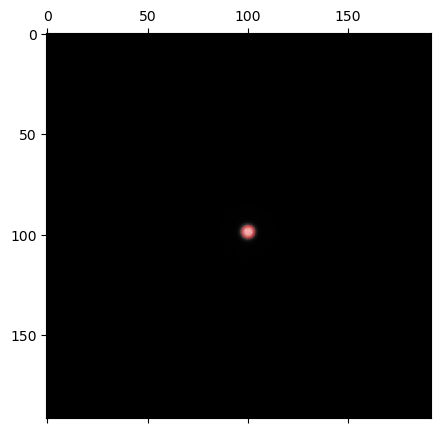

In [6]:
probe_semiangle_px, probe_qx0, probe_qy0  = datacube.get_probe_size(plot = True)

**Standardise text size for all figures**

In [7]:
plt.rcParams.update({
    'font.size': 12,      
    'axes.titlesize': 16,   
    'axes.labelsize': 14,   
    'xtick.labelsize': 11,  
    'ytick.labelsize': 11,  
    'legend.fontsize': 12
})

Visualise Mean Diffraction.

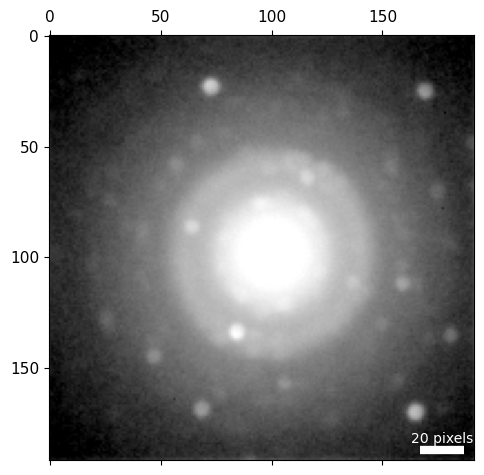

In [8]:
show(datacube.tree('dp_mean'), scaling='log')

### Disk Detection

Disk detection is built on the process of template matching, which determines the intensity values in the data by performing a cross-correlation between a template and an image. 

The process involves:
- Creating a virtual ADF (annular dark field) - measures the scattered electrons
- Select a vacuum region - this selects a region of the data with no sample present
- Generate a probe and prepare probe kernel - creates an image of the beam and uses the extracted data from the vacuum region
- Select scan positions - selecting positions from the sample to obtain the corresponding diffraction patterns
- Disk detection - using detection parameters to obtain the Bragg disks from the diffraction patterns

Note virtual ADF code from: https://github.com/py4dstem/py4DSTEM_tutorials/blob/main/notebooks/GettingStarted.ipynb

Create a virtual ADF by selecting annular positions and overlay with the selected detector position, then plot the ADF. This allows us to visualise the ADF and central beam and the corresponding sample size from the selected region.

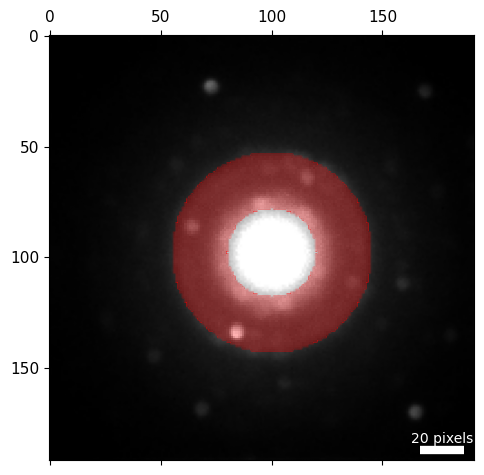

100%|██████████| 900/900 [00:00<00:00, 9552.97it/s]


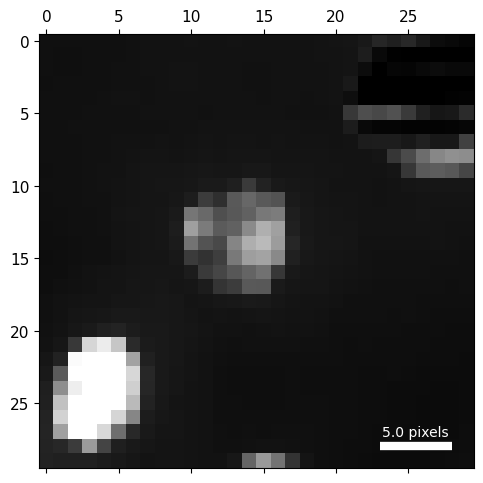

In [9]:
# Virtual ADF
# Selecting annular position
center = 98, 100
r_inner = 20
r_outer = 45
radii = r_inner, r_outer

# Overlay selected detector position over mean dp
datacube.position_detector(
    mode = 'annular',
    geometry = (
        center,
        radii
    )
)

# Capture the virtual ADF
datacube.get_virtual_image(
    mode = 'annulus',
    geometry = (center,radii),
    name = 'annular_dark_field'
)

# Show
show(datacube.tree('annular_dark_field'))

Then select a vacuum region using the mask and show its position on the real space sample.

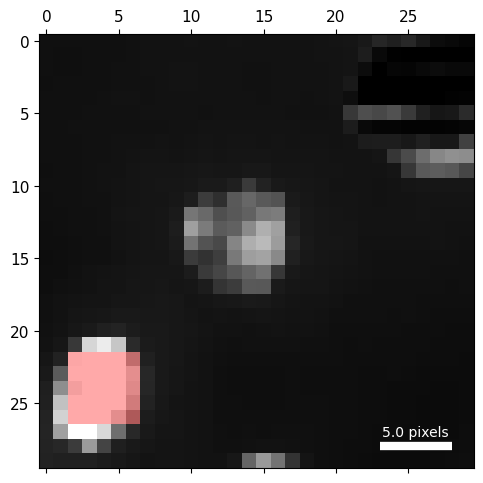

In [10]:
# Select a vacuum region
mask = np.zeros(datacube.Rshape,dtype=bool)
mask[22:27, 2:7] = 1

show(
    datacube.tree('annular_dark_field'), 
    mask = ~mask,
    mask_alpha = 0.667,
    mask_color = 'r'
)

Generate the probe using the vacuum data and apply calibration.

100%|██████████| 24/24 [00:00<00:00, 205.71it/s]


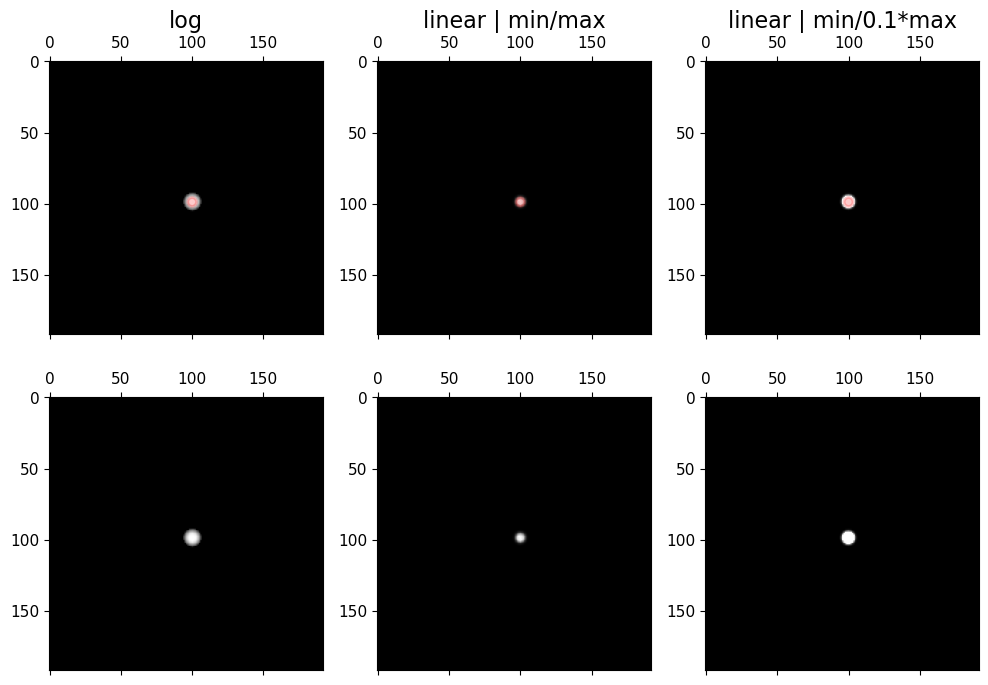

In [11]:
# Generate a probe
probe = datacube.get_vacuum_probe(ROI=mask) 
alpha_pr,qx0_pr,qy0_pr = py4DSTEM.process.calibration.get_probe_size(probe.probe)

Prepare and show the probe kernel.

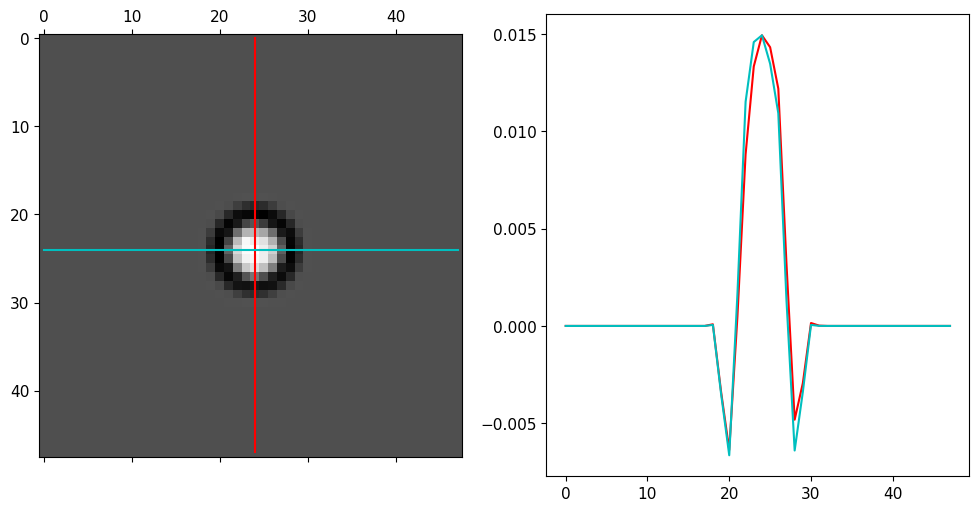

In [12]:
# Prepare the probe kernel
probe.get_kernel(
    mode='sigmoid',
    radii=(alpha_pr,2*alpha_pr)   # the inner and outer radii of the 'trench'
)

py4DSTEM.visualize.show_kernel(
    probe.kernel,
    R = 24,
    L = 24,
    W = 1
)

Select scan positions, choose colour scheme and show the scan positions in the real space and the corresponding virtual diffraction patterns.

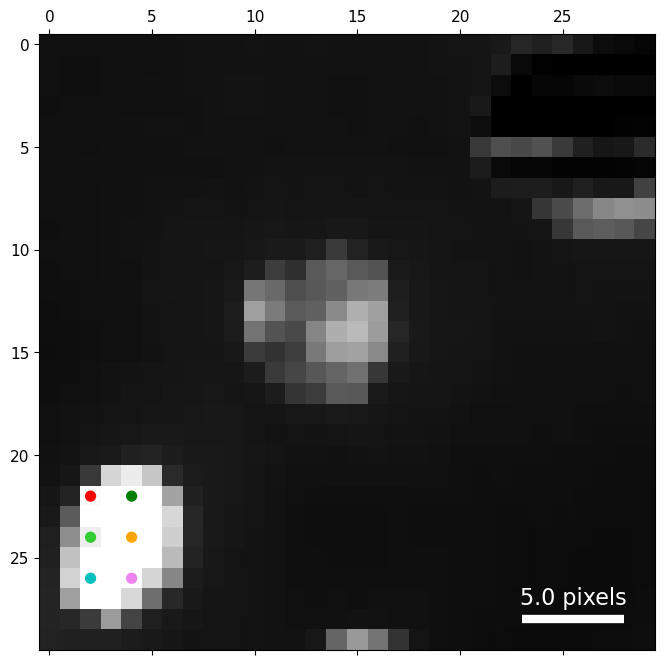

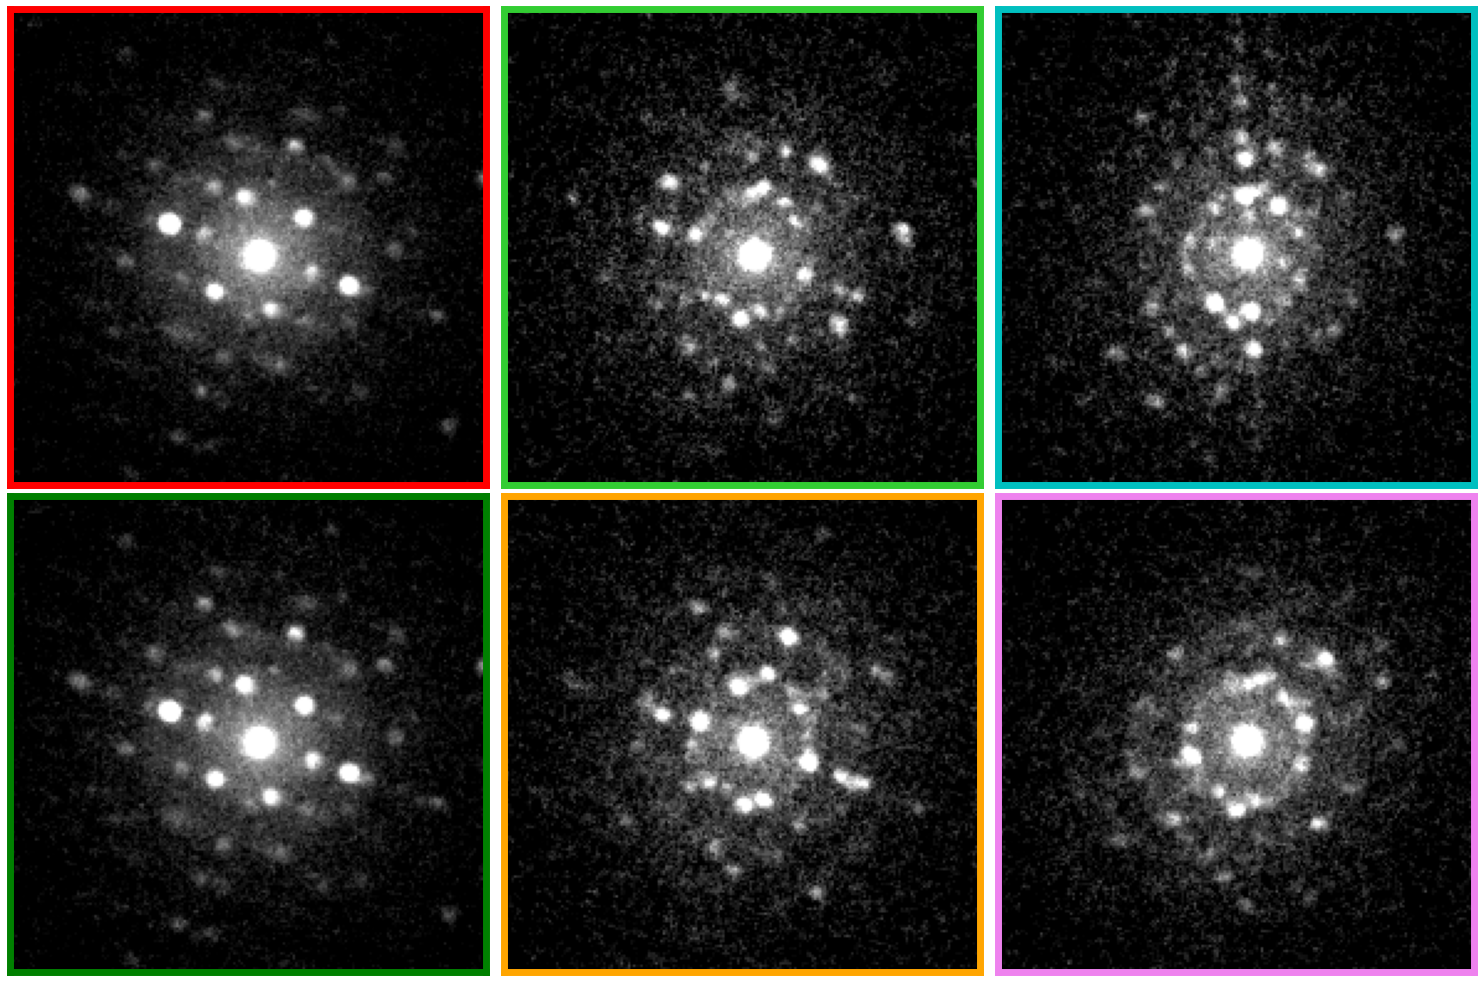

In [15]:
# Select scan positions
rxs = 22, 24, 26, 22, 24, 26
rys = 2, 2, 2, 4, 4, 4

# visualize
colors=['r','limegreen','c','g','orange', 'violet']

# show the selected
# positions in real space
py4DSTEM.visualize.show_points(
    datacube.tree('annular_dark_field'),
    x=rxs,
    y=rys,
    pointcolor=colors,
    figsize=(8,8)
)

# show the selected
# diffraction patterns
py4DSTEM.visualize.show_image_grid(
    get_ar = lambda i:datacube[rxs[i],rys[i],:,:],
    H=2,W=3,
    axsize=(5,5),
    intensity_range='absolute',
    vmin=10,
    vmax=500,
    scaling='power',
    power=0.5,
    get_bordercolor = lambda i:colors[i],
)

Select detection parameters to vary number and positioning of Bragg disks, then find Bragg disks from the datacube by using the probe kernal and detection parameters. Detected Bragg disks are shown.

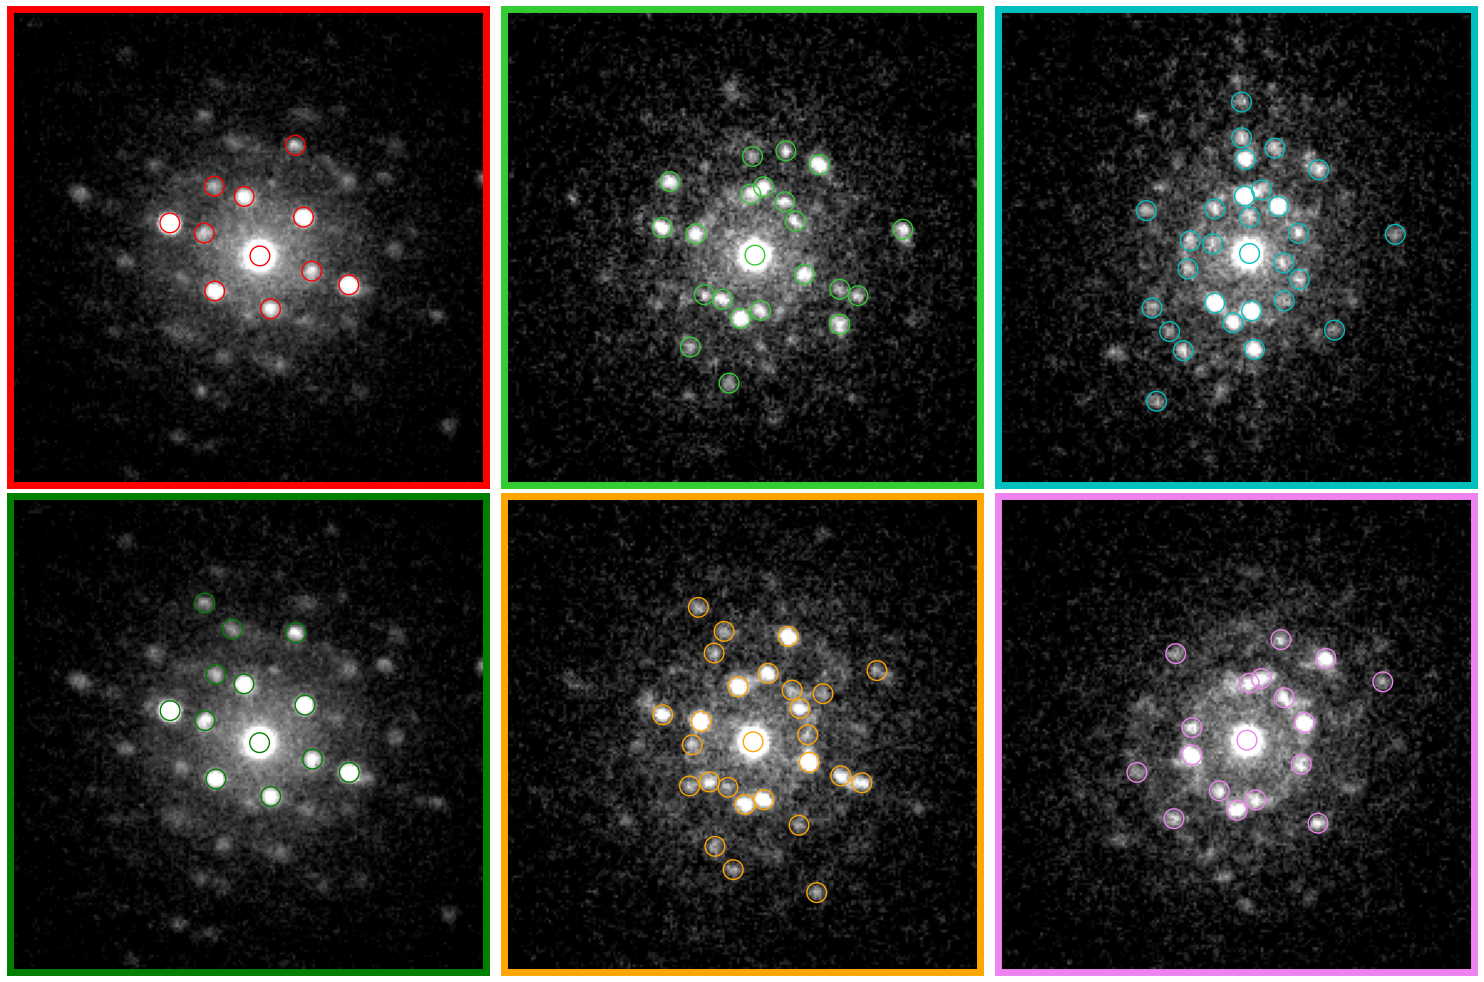

In [16]:
# Perform disk detection
# detection parameters
detect_params = {
    'minAbsoluteIntensity': 25,   # intensity threshold
    'minRelativeIntensity': 0,   # int. thresh. relative to brightest disk in each pattern
    'minPeakSpacing': 5,         # if two peaks are closer than this (in pixels), remove the dimmer peak
    'edgeBoundary': 2,           # remove peaks within this distance of the edge of the diffraction pattern
    'sigma': 0,                  # gaussian blur size to apply to cross correlation before finding maxima
    'maxNumPeaks': 100,          # maximum number of peaks to return, in order of intensity
    'subpixel' : 'poly',         # subpixel resolution method
    'corrPower': 1.0,            # if <1.0, performs a hybrid cross/phase correlation. More sensitive to edges and to noise
#     'CUDA': True,              # if a GPU is configured and cuda dependencies are installed, speeds up calculation 
}

# find disks for selected patterns
disks_selected = datacube.find_Bragg_disks(
    data = (rxs, rys),
    template = probe.kernel,
    **detect_params,
)

# show
py4DSTEM.visualize.show_image_grid(
    get_ar = lambda i:datacube[rxs[i],rys[i],:,:],
    H=2, 
    W=3,
    axsize=(5,5),
    intensity_range='absolute',
    vmin=10,
    vmax=500,
    scaling='power',
    power=0.5,
    get_bordercolor = lambda i:colors[i],
    get_x = lambda i: disks_selected[i].data['qx'],
    get_y = lambda i: disks_selected[i].data['qy'],
    get_pointcolors = lambda i: colors[i],
    open_circles = True,
    scale = 200,
)

### Find Bragg Disks and save Bragg peaks data

Find the detected Bragg disks and save under braggpeaks.

In [17]:
# compute for all diffraction patterns and find peaks
braggpeaks = datacube.find_Bragg_disks(
    template = probe.kernel,
    **detect_params,
)

Finding Bragg Disks: 100%|██████████| 900/900 [00:03<00:00, 291DP/s] 


Choose filepath and filename.

In [18]:
filename_bragg_2 = 'BraggPeakData/Example_braggpeaks.h5'

Use py4DSTEM.save to save the braggpeaks data.

In [19]:
py4DSTEM.save(filename_bragg_2, braggpeaks, mode='o')

100%|██████████| 900/900 [00:00<00:00, 6651.60it/s]


Inspect the filepath structure.

In [20]:
py4DSTEM.print_h5_tree(filename_bragg_2)

/
|---datacube_root
    |---braggvectors
        |---_v_uncal




Reload the data.

In [21]:
#optional reload
braggpeaks = py4DSTEM.read(filename_bragg_2, root='/datacube_root/braggvectors')

Reading PointListArray: 100%|██████████| 900/900 [00:00<00:00, 5826.79PointList/s]
